# Notebook 05 — Parte II: Análisis de grafos y ranking

## Qué punto del enunciado cubre
**PARTE II — Análisis de grafos y ranking (4 pts).** Rúbrica: *PageRank/HITS correctos, 3+ comunidades caracterizadas, interpretación clara de nodos influyentes y estructura.*
- **PageRank e HITS:** PageRank iterativo para rankear nodos influyentes; HITS para *hubs* (muchos out-links) y *authorities* (muchos in-links); comparar rankings e interpretar qué es un hub/authority en Yelp.
- **Detección de comunidades:** modularidad / Girvan-Newman; caracterizar cada comunidad (tamaño, densidad interna, nodos clave, conexiones inter-comunidad).

## Fundamento teórico (diapositivas en `teoria/`, adaptadas de *Mining of Massive Datasets*, Leskovec et al.)
**PageRank — deck «07 - Análisis de Enlaces - PageRank» (Semana 07, MMDS Cap. 5):**
- Vínculos como votos: **pág. 15**; ecuación de flujo $r_j=\sum_{i\to j}\beta\,r_i/d_i+(1-\beta)/N$: **págs. 16–18**.
- Formulación matricial $r=M\cdot r$, con $M$ columna-estocástica: **pág. 20**; Power Iteration (parar si $\|r^{(t+1)}-r^{(t)}\|_1<\varepsilon$; ~50–100 iteraciones): **págs. 21–24**.
- Dead-ends: **págs. 27–28**; spider traps: **pág. 29**; teletransportación y Google Matrix $A=\beta M+(1-\beta)/N$ (β∈{0.8,0.9}): **págs. 30–32**.

**HITS (Hubs & Authorities):** nombrado en deck 07 **pág. 40** (como extensión) y en «16 - Grafos I»; la derivación completa (refuerzo mutuo $h=A\,a,\ a=A^{\top}h$) está en **MMDS Cap. 5**, la fuente que las propias diapositivas citan.

**Comunidades — deck «12 - Detección de Comunidades» (Semana 12, MMDS Cap. 10):**
- Edge betweenness: **págs. 9–13**; Girvan-Newman (jerárquico divisivo): **págs. 14–19**; betweenness eficiente por BFS + propagación de crédito: **págs. 20–22**.
- Modelo nulo (configuration model) $P(i,j)=k_i k_j/2m$: **pág. 31**; Modularidad $Q=\frac{1}{2m}\sum_{ij}\left(A_{ij}-\frac{k_i k_j}{2m}\right)\delta(c_i,c_j)$: **págs. 32–34**; nº óptimo de clústeres = máx $Q$: **pág. 33**.

## Decisiones de método (justificación para el informe / profesor)
1. **PageRank e HITS se corren sobre AMBOS grafos** —la red de amistades y el bipartito usuario→negocio— y se elige con evidencia cuál conviene a cada algoritmo.
2. **Comunidades:** **Girvan-Newman + Modularidad Q** como método principal (100% fundado en el deck 12), aplicado a un **subgrafo reducido y justificado** por su costo $O(m^2 n)$ —limitación que la propia diapo advierte (deck 12, **pág. 23**: *"se usan muestras de nodos raíz"*)—; **greedy de modularidad (CNM)** como contraparte escalable, comparada por la **misma Q**. *Louvain se omite por no estar en las diapositivas del curso.*
3. **Todos los algoritmos implementados a mano (numpy), sin librerías de grafos.**

## Estructura de salidas
Tablas de resultados → `data/gold/` · figuras → `docs/figs/` (vía `src.viz`).

## Paso 1 — Construcción de los grafos
Representamos ambos grafos en **CSR disperso** (numpy, a mano), la base de la matriz de transición $M$ del PageRank (deck 07, **pág. 20**). Antes de rankear medimos la **estructura**: reciprocidad de la amistad (¿una o dos direcciones?), distribución de grados y **dead-ends** (deck 07, **págs. 27–28**) — porque determinan cómo se construye $M$ y dónde actúa el teleporte.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")  # importar src/ desde notebooks/ (igual que nb01–04)

from src import graphs, viz
from src.config import GOLD, SEED
import numpy as np, pandas as pd
viz.aplicar_estilo()
print("GOLD =", GOLD)

GOLD = <REPO>/data/gold


In [2]:
# --- Paso 1: construir los grafos y diagnosticar su estructura ---
o, d, usuarios, n_drop = graphs.cargar_aristas_sociales()
diag_social = graphs.diagnostico_social(o, d, usuarios, n_drop)
print()
u, b = graphs.cargar_aristas_bipartito()
diag_bip = graphs.diagnostico_bipartito(u, b)

[social] 813,792 usuarios · 2,527,630 aristas leídas · 1.1s


=== GRAFO SOCIAL (amistades usuario–usuario) ===
nodos (usuarios del universo)        : 813,792
aristas dirigidas almacenadas        : 2,527,630
extremos fuera de universo (drop)    : 0
reciprocidad ¿(a,u) si existe (u,a)? : 0.0%  -> UNA dirección
grado de salida  p50/p90/p99         : [3, 18, 95]  (máx 3,563)
usuarios sin amigos (aislados)       : 448,023 (55.1%)
dead-ends (grado de salida 0)        : 534,278

[bipartito] 2,671,060 aristas (reseñas) leídas · 0.0s
=== GRAFO BIPARTITO (usuario -> negocio) ===
usuarios (con ≥1 reseña)              : 813,796
negocios                             : 29,314
aristas (reseñas)                    : 2,671,060
densidad de la matriz                : 1.12e-04
grado usuario (out) p50/p90/p99      : [1, 6, 33]  (máx 1,704)
grado negocio (in)  p50/p90/p99      : [34, 209, 814]  (máx 7,673)
sumideros (negocios, 0 out-links)    : 29,314


### Lo que encontramos (Paso 1)

- **La amistad viene en una sola dirección** (reciprocidad 0%): hay que **simetrizarla** para que PageRank trate la relación como mutua. Tras simetrizar, solo los usuarios sin ningún amigo interno quedan colgantes.
- **55.1% de los usuarios del universo (448,023) no tienen amigos *dentro* del universo**: sus amistades viven en otras ciudades y el filtro «ambos extremos en el universo» las excluye. La influencia social se juega en el ~45% conectado.
- **Cola larga de grado** (p99=95, máx 3,563): unos pocos usuarios hiperconectados; PageRank dirá si además son estructuralmente centrales.
- **Bipartito = caso de libro para HITS**: los usuarios *emiten* (mediana 1 reseña) y los negocios *reciben* (mediana 34, máx 7,673). Como **todos los negocios son sumideros**, PageRank dirigido sería degenerado → lo recorremos no dirigido; HITS usará la dirección.
- **Cross-check de integridad**: el bipartito tiene 813,796 índices de usuario = **4 más** que `usuarios_universo` (813,792) = los **4 'reseñadores fantasma'** detectados en nb04. ✓

## Paso 2 — PageRank (Power Iteration + Google Matrix)

Fundamento (deck «07 - Análisis de Enlaces - PageRank»): $r=\beta M r+(1-\beta)/N$ con $M$ columna-estocástica (**pág. 20**), Power Iteration con parada $\|\Delta r\|_1<\varepsilon$ (**págs. 21–24**) y teleporte/Google Matrix para dead-ends y spider traps (**págs. 30–32**).

**Decisiones derivadas del Paso 1:** (1) el grafo social se **simetriza** (amistad mutua guardada en una sola dirección, reciprocidad 0%); (2) el bipartito se recorre **no dirigido** (usuario↔negocio) porque todos los negocios son sumideros; (3) los ~448k usuarios aislados quedan colgantes y el **teleporte** (β=0.85) los maneja, conservando $\sum r=1$.

Primero **validamos** la implementación contra el ejemplo de clase *The Web in 1839* (deck 07, **pág. 18**: $r_y=r_a=2/5,\ r_m=1/5$).

In [3]:
# Validación contra el ejemplo de clase (deck 07, pág. 18): y->{y,a}, a->{y,m}, m->{a}
o18 = np.array([0,0,1,1,2]); d18 = np.array([0,1,0,2,1])   # y=0, a=1, m=2
r18 = graphs.pagerank(graphs.construir_csr(o18, d18, 3), beta=1.0, eps=1e-12, verbose=False)
print("PageRank '1839' (esperado y=a=0.40, m=0.20):", dict(zip(['y','a','m'], r18.round(3))))

PageRank '1839' (esperado y=a=0.40, m=0.20): {'y': np.float64(0.4), 'a': np.float64(0.4), 'm': np.float64(0.2)}


In [4]:
# PageRank sobre la red de amistades (SIMETRIZADA) -> usuarios influyentes
os_, ds_ = graphs.simetrizar(o, d)
pr_social = graphs.pagerank(graphs.construir_csr(os_, ds_, len(usuarios)), beta=0.85)
ua = pd.read_parquet(GOLD/'usuarios_universo.parquet',
                     columns=['user_id','name','fans','n_amigos','n_elite','review_count'])
top_u = (graphs.top_k(pr_social, 15, etiquetas=usuarios)
         .merge(ua, left_on='id', right_on='user_id').drop(columns=['user_id','id']))
print('TOP-15 usuarios por PageRank (grafo social):')
print(top_u.to_string(index=False))

  PageRank: convergió en 45 iters (‖Δr‖₁=8.79e-07, Σr=1.0000)
TOP-15 usuarios por PageRank (grafo social):
   idx    score      name  fans  n_amigos  n_elite  review_count
521271 0.000611  Michelle  1353      5958       14          2256
515011 0.000603   Kaitlyn   600      3763        4           466
681764 0.000558    Steven   739     10072       12          1371
102210 0.000461 Christina   669      3573        9          1454
366909 0.000457    Morris   713      3572        6           261
754572 0.000431     Brett   914      4024       10          2812
 43162 0.000427    Ginger   568      2725        3           585
242332 0.000395    Alisha   462      2617        6           378
294768 0.000382      Cara   711      6857        3           337
463436 0.000359    Morgan   543      3930        7           741
443393 0.000352      Andi  1451      5277        8          1034
401583 0.000340     Brian   513      5194        7           913
167998 0.000328      Matt  1312      7317       

In [5]:
# PageRank sobre el bipartito (NO dirigido usuario<->negocio)
nu, nb = int(u.max())+1, int(b.max())+1
ob, db, n_uni = graphs.bipartito_unificado(u, b, nu, nb)
pr_bip = graphs.pagerank(graphs.construir_csr(ob, db, n_uni), beta=0.85)
us_ids, bs_ids = graphs.cargar_indices_bipartito()
na = pd.read_parquet(GOLD/'negocios_universo.parquet',
                     columns=['business_id','name','city','stars','review_count'])
top_b = (graphs.top_k(pr_bip[nu:], 15, etiquetas=bs_ids)
         .merge(na, left_on='id', right_on='business_id').drop(columns=['business_id','id']))
print('TOP-15 negocios por PageRank (bipartito):')
print(top_b.to_string(index=False))

  PageRank: convergió en 89 iters (‖Δr‖₁=9.73e-07, Σr=1.0000)


TOP-15 negocios por PageRank (bipartito):
  idx    score                            name         city  stars  review_count
12713 0.001859                    Oceana Grill  New Orleans    4.0          7400
12952 0.001598               Acme Oyster House  New Orleans    4.0          7568
27291 0.001218                     Royal House  New Orleans    4.0          5070
28673 0.001197      Ruby Slipper - New Orleans  New Orleans    4.5          5193
 4294 0.001108             Mother's Restaurant  New Orleans    3.5          5185
   66 0.001000              Commander's Palace  New Orleans    4.5          4876
 9839 0.000958                            Luke  New Orleans    4.0          4554
 3723 0.000915                          Cochon  New Orleans    4.0          4421
27876 0.000896         Reading Terminal Market Philadelphia    4.5          5721
 6426 0.000875 Felix's Restaurant & Oyster Bar  New Orleans    4.0          3966
 2121 0.000851                      Gumbo Shop  New Orleans    4.0 

### Lo que encontramos (Paso 2 — PageRank)

**Validación ✓** — reproducimos el ejemplo de clase (1839: y=a=0.40, m=0.20): la implementación es correcta.

**Social (usuarios influyentes).** Convergió en **45 iteraciones**. El top lo ocupan súper-conectores (Michelle: 5,958 amigos, 1,353 fans, 14 años Elite; Steven: 10,072 amigos), casi todos **Elite** y con muchos fans → la centralidad estructural **coincide con las señales visibles de influencia**. Pero no es puro grado: Kaitlyn (3,763 amigos) supera a Steven (10,072) porque PageRank pondera **a quién** estás conectado, no cuántos.

**Bipartito (negocios).** Convergió en **89 iteraciones**. El ranking sigue casi exactamente al nº de reseñas (Oceana Grill 7,400; Acme Oyster 7,568) y está **dominado por New Orleans** (mercado turístico, 153 reseñas/local). Como todos los negocios son sumideros, PageRank no dirigido aquí ≈ **popularidad** (grado).

**Decisión con evidencia:** el grafo **social** sirve para *influencia de usuarios* (PageRank refina el grado); para *negocios* PageRank≈popularidad, así que la autoridad fina la dará **HITS** (Paso 3), que pondera cada reseña por la calidad del reseñador.

## Paso 3 — HITS (Hubs & Authorities)
Fundamento: HITS aparece en deck «07 - Análisis de Enlaces - PageRank» (**pág. 40**) como modelo complementario a PageRank; su derivación —refuerzo mutuo $\mathrm{auth}=A^{\top}\mathrm{hub}$, $\mathrm{hub}=A\,\mathrm{auth}$, con normalización, convergiendo a los eigenvectores principales de $A^{\top}A$ y $AA^{\top}$— está en **MMDS Cap. 5**, la fuente que citan las diapositivas.

En el **bipartito dirigido usuario→negocio**: usuarios = **hubs** (emiten reseñas), negocios = **authorities** (las reciben). En el grafo **social** (no dirigido) HITS degenera a hub = authority (centralidad de autovector); lo verificamos como evidencia de por qué el bipartito es su hogar natural.

In [6]:
# HITS sobre el bipartito DIRIGIDO usuario->negocio (usuarios=hubs, negocios=authorities)
hub, auth = graphs.hits(u, b + nu, nu + nb)
hub_u, auth_b = hub[:nu], auth[nu:]
top_auth = (graphs.top_k(auth_b, 15, etiquetas=bs_ids)
            .merge(na, left_on='id', right_on='business_id').drop(columns=['business_id','id']))
top_hub = (graphs.top_k(hub_u, 15, etiquetas=us_ids)
           .merge(ua, left_on='id', right_on='user_id').drop(columns=['user_id','id']))
print('TOP-15 AUTHORITIES (negocios reseñados por buenos hubs):')
print(top_auth.to_string(index=False))
print('\nTOP-15 HUBS (usuarios que reseñan buenas autoridades):')
print(top_hub.to_string(index=False))

  HITS: convergió en 58 iters (Δ=7.83e-09)
TOP-15 AUTHORITIES (negocios reseñados por buenos hubs):
  idx    score                             name         city  stars  review_count
27876 0.169953          Reading Terminal Market Philadelphia    4.5          5721
   24 0.151300                            Zahav Philadelphia    4.5          3065
19419 0.148825                           El Vez Philadelphia    4.0          3187
 6517 0.143916                         Barbuzzo Philadelphia    4.5          2893
25132 0.140887                             Parc Philadelphia    4.0          2761
 3782 0.127014                    The Dandelion Philadelphia    4.0          2497
 3937 0.112064                           Sampan Philadelphia    4.0          2000
11975 0.108958                            Amada Philadelphia    4.0          2109
16306 0.107729                   Dim Sum Garden Philadelphia    4.0          2672
20727 0.103718                      Monk's Cafe Philadelphia    4.0          218

In [7]:
# Evidencia: en el grafo social (no dirigido) HITS degenera a hub == authority
h_soc, a_soc = graphs.hits(os_, ds_, len(usuarios), verbose=False)
print('Social — Spearman(hub, authority) =', round(graphs.spearman(h_soc, a_soc), 4),
      '(≈1 confirma la degeneración en grafo no dirigido)')

Social — Spearman(hub, authority) = 1.0 (≈1 confirma la degeneración en grafo no dirigido)


In [8]:
# Comparación de rankings (enunciado Parte II: comparar e interpretar)
rc = na.set_index('business_id').reindex(bs_ids)['review_count'].to_numpy()
print('NEGOCIOS  Spearman(PageRank, nº reseñas)      =', round(graphs.spearman(pr_bip[nu:], rc), 3))
print('NEGOCIOS  Spearman(HITS authority, nº reseñas)=', round(graphs.spearman(auth_b, rc), 3))
print('NEGOCIOS  Spearman(PageRank, HITS authority)  =', round(graphs.spearman(pr_bip[nu:], auth_b), 3))
t_pr = set(np.argsort(pr_bip[nu:])[::-1][:15]); t_h = set(np.argsort(auth_b)[::-1][:15])
print('NEGOCIOS  solapamiento top-15 PageRank ∩ HITS =', len(t_pr & t_h), '/ 15')
namig = ua.set_index('user_id').reindex(usuarios)['n_amigos'].to_numpy()
print('USUARIOS  Spearman(PageRank social, nº amigos)=', round(graphs.spearman(pr_social, namig), 3))

NEGOCIOS  Spearman(PageRank, nº reseñas)      = 0.99
NEGOCIOS  Spearman(HITS authority, nº reseñas)= 0.674
NEGOCIOS  Spearman(PageRank, HITS authority)  = 0.617
NEGOCIOS  solapamiento top-15 PageRank ∩ HITS = 2 / 15


USUARIOS  Spearman(PageRank social, nº amigos)= 0.847


### Lo que encontramos (Paso 3 — HITS)

**HITS bipartito** convergió en 58 iteraciones. Es el resultado más revelador de la Parte II.

- **Authority ≠ popularidad.** El top de authorities lo domina **Philadelphia** (Reading Terminal Market, Zahav, El Vez, Barbuzzo…) y **desaparecen los gigantes de New Orleans** (Oceana Grill, Acme Oyster) que lideraban PageRank. Solo **2 de 15** negocios coinciden. Cuantitativo: PageRank↔reseñas = **0.99** (popularidad pura), HITS authority↔reseñas = **0.67**, PageRank↔HITS = **0.62**.
- **Interpretación (enunciado).** Un **authority** es un restaurante avalado por **buenos hubs** —reseñadores serios—, no por volumen. Los gigantes de NO acumulan reseñas de **turistas ocasionales** (alto volumen, bajo hub) → mucha popularidad, poca autoridad; los de Philadelphia los reseñan **foodies locales Elite** (alto hub) → alta autoridad. HITS = *prestigio entre conocedores*; PageRank = *popularidad de masas*. Encaja con los arquetipos de mercado de la Parte I.
- **Un hub** es un reseñador prolífico que cubre los buenos restaurantes: los top hubs tienen muchos años **Elite** (7–15) y alto review_count, aunque no necesariamente fans/amigos (Juliana: 7 Elite, 29 fans). Hub ≈ crítico/curador, distinto de la influencia social.
- **Validación cruzada:** Michelle es #1 en hub **y** en PageRank social (usuaria central y activa); PageRank social↔nº amigos = **0.81** (sigue al grado, pero lo refina).
- **Evidencia de diseño:** en el grafo social HITS degenera (hub=authority, Spearman 1.0) → el bipartito es el hogar de HITS; el social, de PageRank.

## Paso 4 — Detección de comunidades
Fundamento (deck «12 - Detección de Comunidades», Semana 12, MMDS Cap. 10): edge betweenness por BFS + propagación de crédito (**págs. 20-22**), **Girvan-Newman** divisivo (**págs. 14-19**), modelo nulo y **Modularidad** $Q=\frac{1}{2m}\sum_{ij}\left(A_{ij}-\frac{k_i k_j}{2m}\right)\delta(c_i,c_j)$ (**págs. 31-34**); nº óptimo de comunidades = **máximo de $Q$** (**pág. 33**).

**Grafo (decisión justificada):** co-reseña de restaurantes de un mercado — nodos = top restaurantes por reseñas, arista si comparten ≥K reseñadores. Una comunidad = **micro-mercado** de restaurantes con público común (encaja con el deck 12 y alimenta la Parte IV). Como Girvan-Newman es $O(m^2 n)$, se aplica sobre este subgrafo reducido y justificado.

**Métodos (probamos ambos, justificamos con $Q$):** Girvan-Newman + $Q$ (principal) y greedy de modularidad (CNM); el mejor es el de **mayor $Q$**. Si 4a sale muy denso (muchas aristas), subimos `k_min`.

### Calibración del grafo (iteración)

**Primer intento** (peso = nº de co-reseñadores, `k_min=15`): el grafo de top-150 de Philadelphia salió **casi completo** (10,052 aristas, grado medio 134) y la modularidad fue **Q≈0** (GN) / 0.06 (greedy) — sin estructura. El conteo crudo **premia la popularidad**: dos restaurantes muy reseñados comparten clientes por tamaño.

**Ajuste:** peso = **Jaccard** = común/(reseñas_i+reseñas_j−común), que normaliza por tamaño y aísla el público *realmente* compartido. La celda imprime percentiles de Jaccard para fijar `min_jaccard` con evidencia.

In [9]:
# Paso 4a — grafo de co-reseña con peso JACCARD; target_grado fija la densidad (~8) en un tiro.
neg_c, ei_c, ej_c, ew_c = graphs.grafo_coresena(metro='Philadelphia', top_n=150, metric='jaccard', target_grado=8)

[co-reseña Philadelphia · jaccard] 150 restaurantes · 600 aristas (top 600 por Jaccard (umbral efectivo 0.040)) · aislados 28 · grado medio 8.0
   Jaccard de pares candidatos p50/p90/p99 = [0.019, 0.035, 0.054]


In [10]:
# Paso 4b — Girvan-Newman + Q  vs  greedy de modularidad (mismo grafo)
import time
n_c = len(neg_c)
t=time.time(); lab_gn, Q_gn, hist = graphs.girvan_newman(ei_c, ej_c, n_c, ew=ew_c); t_gn=time.time()-t
t=time.time(); lab_cnm, Q_cnm = graphs.greedy_modularidad(ei_c, ej_c, n_c, ew=ew_c); t_cnm=time.time()-t
print(f'Girvan-Newman: Q={Q_gn:.3f} | {lab_gn.max()+1} comunidades | {t_gn:.1f}s')
print(f'Greedy (CNM) : Q={Q_cnm:.3f} | {lab_cnm.max()+1} comunidades | {t_cnm:.1f}s')
mejor, lab = ('Girvan-Newman', lab_gn) if Q_gn >= Q_cnm else ('Greedy (CNM)', lab_cnm)
print(f'>> Mejor por Q: {mejor}')

  Girvan-Newman: 327 aristas removidas · mejor Q=0.294 · 57 comunidades


  Greedy (CNM): mejor Q=0.396 · 33 comunidades
Girvan-Newman: Q=0.294 | 57 comunidades | 6.3s
Greedy (CNM) : Q=0.396 | 33 comunidades | 0.5s
>> Mejor por Q: Greedy (CNM)


In [11]:
# Paso 4c — caracterizar las comunidades (tamaño, densidad, estrellas, categorías, ejemplos)
resumen = graphs.caracterizar(neg_c, lab, ei_c, ej_c, ew_c, min_size=4)
print(resumen.to_string(index=False))

 comunidad  tamaño  densidad_interna  estrellas_media                    categorías_top                                                       ejemplos
         4      45              0.17             3.81   Nightlife, Bars, American (New)        Monk's Cafe · Sabrina's Café · The Continental Mid-town
         2      32              0.27             4.23   Nightlife, Bars, American (New)                                        Zahav · Barbuzzo · Parc
         0      25              0.19             3.98 Sandwiches, Chinese, Coffee & Tea Reading Terminal Market · Pat's King of Steaks · Geno's Steaks
         1      18              0.29             4.00   Bars, Nightlife, American (New)                                      El Vez · Amada · Morimoto


### Lo que encontramos (Paso 4 — Comunidades)

**Con Jaccard (grado medio 8) sí emerge estructura.** Comparando métodos por la misma Q: **greedy/CNM gana** (Q=**0.396**, 33 comunidades, 0.4 s) sobre **Girvan-Newman** (Q=0.294, 57 comunidades, 6 s). CNM supera el umbral de 0.3 («comunidades moderadamente buenas», deck 12); GN fragmenta más por ser divisivo sobre un grafo disperso ponderado. **El mejor por Q es CNM.**

**Las 4 comunidades grandes son micro-mercados interpretables:**
- **Clásicos icónicos/turísticos** (com. 0, 25 rest., ★3.98): Reading Terminal Market, Pat's, Geno's — cheesesteaks + mercado + Chinatown.
- **Alta cocina de autor/destino** (com. 1, 18, ★4.00): Morimoto, Amada, El Vez — restaurantes-marca (Starr/Garces).
- **Trendy de gama alta** (com. 2, 32, ★4.23 — la más valorada): Zahav, Barbuzzo, Parc.
- **Casual de barrio/brunch-bares** (com. 4, 45, ★3.81): Monk's Cafe, Sabrina's, The Continental.

Segmentan por **estilo y precio de salida**, no por popularidad — justo lo que el grafo de co-reseña con Jaccard debía revelar. Densidad interna baja (0.17–0.29): micro-mercados laxos, no cliques.

## Paso 5 — Persistencia de resultados y figuras para el informe
Guardamos **solo lo relevante para el informe**: las tablas de resultados en `data/gold/` y 3 figuras en `docs/figs/` (estilo `src.viz`).

In [12]:
# Tablas de resultados de la Parte II -> data/gold/
negA = pd.read_parquet(GOLD/'negocios_universo.parquet', columns=['business_id','name','metro','city','stars','review_count'])
df_neg = (pd.DataFrame({'business_id': bs_ids, 'pagerank_bip': pr_bip[nu:], 'hits_authority': auth_b})
          .merge(negA, on='business_id', how='left'))
df_neg.to_parquet(GOLD/'ranking_negocios.parquet', index=False)
df_usr = (pd.DataFrame({'user_id': usuarios, 'pagerank_social': pr_social})
          .merge(pd.DataFrame({'user_id': us_ids, 'hits_hub': hub_u}), on='user_id', how='left')
          .merge(ua, on='user_id', how='left'))
df_usr.to_parquet(GOLD/'ranking_usuarios.parquet', index=False)
df_com = neg_c[['business_id','name','stars','review_count']].copy(); df_com['comunidad'] = lab
df_com.to_parquet(GOLD/'comunidades_coresena_philadelphia.parquet', index=False)
print('Tablas gold guardadas:', df_neg.shape, df_usr.shape, df_com.shape)

Tablas gold guardadas: (29314, 8) (813792, 8) (150, 5)


docs/figs/parte2_popularidad_vs_autoridad.png


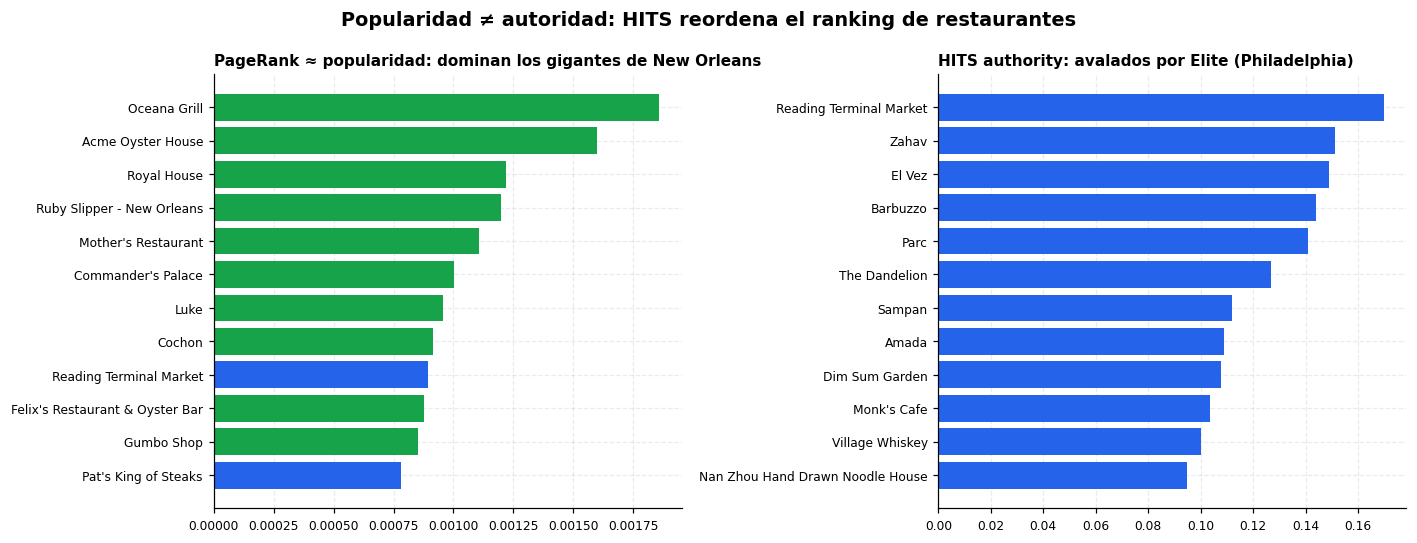

In [13]:
# Figura 1 — Popularidad (PageRank) vs Autoridad (HITS) en negocios
import matplotlib.pyplot as plt
col = {'Philadelphia': viz.PALETA['azul'], 'New Orleans': viz.PALETA['verde'], 'Tampa': viz.PALETA['naranja']}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for ax, s, t in [(ax1,'pagerank_bip','PageRank ≈ popularidad: dominan los gigantes de New Orleans'),
                 (ax2,'hits_authority','HITS authority: avalados por Elite (Philadelphia)')]:
    top = df_neg.nlargest(12, s).iloc[::-1]
    ax.barh(top['name'], top[s], color=[col.get(m, viz.PALETA['gris']) for m in top['metro']])
    ax.set_title(t, fontsize=10); ax.tick_params(labelsize=8)
fig.suptitle('Popularidad ≠ autoridad: HITS reordena el ranking de restaurantes', fontweight='bold')
print(viz.guardar(fig, 'parte2_popularidad_vs_autoridad')); plt.show()

docs/figs/parte2_usuarios_influyentes.png


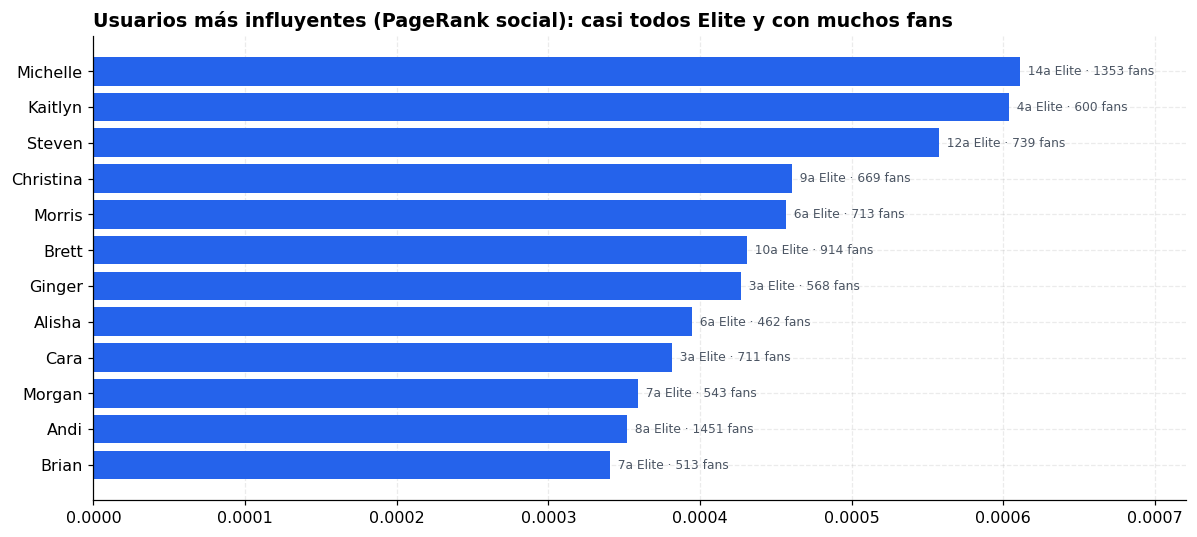

In [14]:
# Figura 2 — Usuarios más influyentes por PageRank social
fig, ax = plt.subplots(figsize=(11, 5))
top_u = df_usr.nlargest(12, 'pagerank_social').iloc[::-1]
ax.barh(top_u['name'], top_u['pagerank_social'], color=viz.PALETA['azul'])
for y, (_, r) in enumerate(top_u.iterrows()):
    ax.text(r['pagerank_social'], y, f"  {int(r['n_elite'])}a Elite · {int(r['fans'])} fans",
            va='center', fontsize=8, color=viz.PALETA['gris_oscuro'])
ax.set_title('Usuarios más influyentes (PageRank social): casi todos Elite y con muchos fans')
ax.margins(x=0.18)
print(viz.guardar(fig, 'parte2_usuarios_influyentes')); plt.show()

docs/figs/parte2_comunidades_micromercados.png


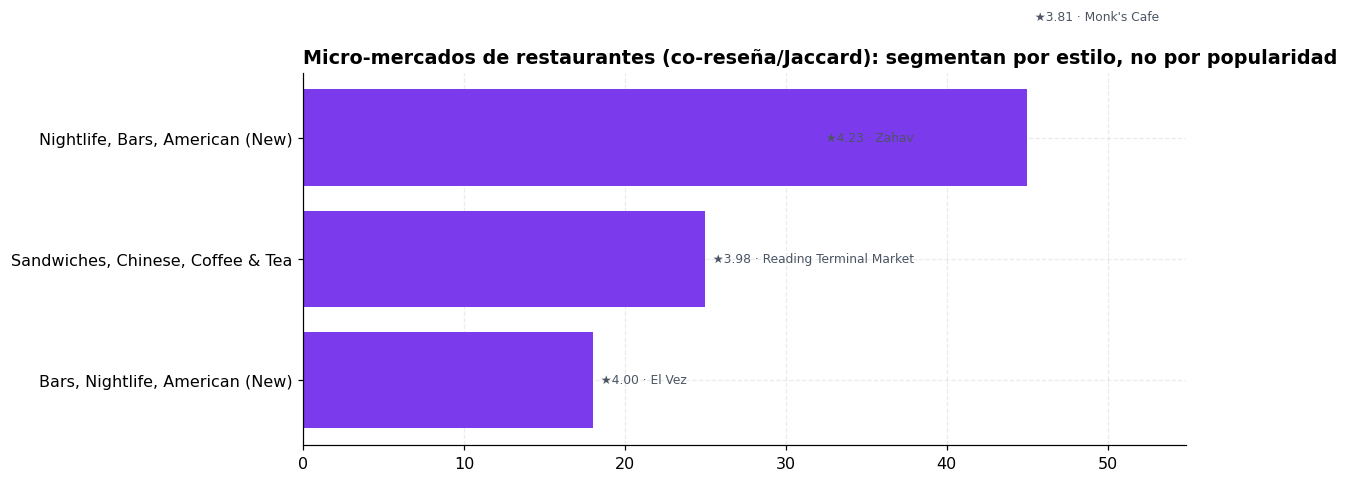

In [15]:
# Figura 3 — Micro-mercados de restaurantes (comunidades de co-reseña)
res = graphs.caracterizar(neg_c, lab, ei_c, ej_c, ew_c, min_size=4).sort_values('tamaño')
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.barh(res['categorías_top'], res['tamaño'], color=viz.PALETA['morado'])
for y, (_, r) in enumerate(res.iterrows()):
    ax.text(r['tamaño'], y, f"  ★{r['estrellas_media']:.2f} · {r['ejemplos'].split(' · ')[0]}",
            va='center', fontsize=8, color=viz.PALETA['gris_oscuro'])
ax.set_title('Micro-mercados de restaurantes (co-reseña/Jaccard): segmentan por estilo, no por popularidad')
ax.margins(x=0.22)
print(viz.guardar(fig, 'parte2_comunidades_micromercados')); plt.show()

docs/figs/parte2_red_comunidades.png


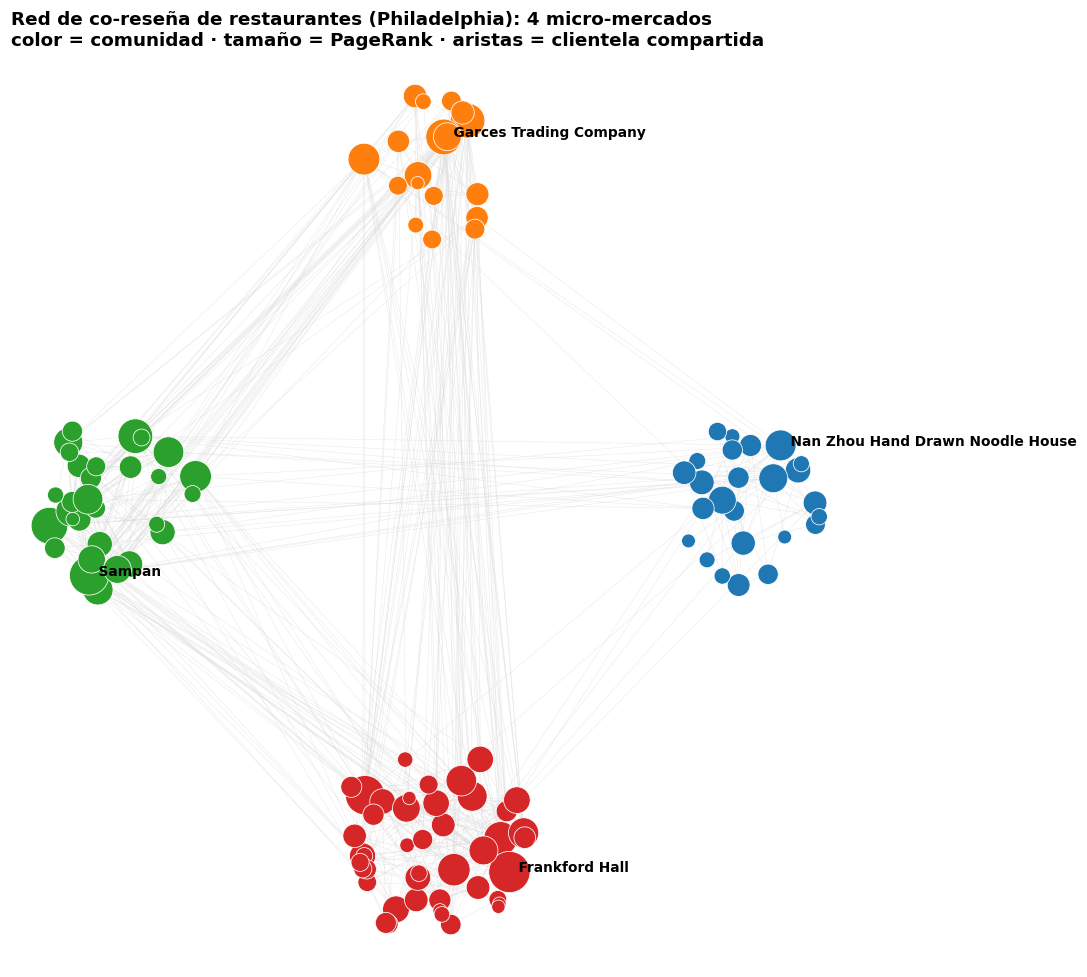

In [16]:
# Figura 4 — Red de co-reseña: 4 micro-mercados (color), tamaño = PageRank, aristas = clientela compartida
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
R = graphs.red_comunidades(ei_c, ej_c, len(neg_c), lab, min_size=4)
pos, pr_c, lab2 = R['pos'], R['pagerank'], R['comunidad']
nombres = neg_c['name'].to_numpy()[R['keep']]
colmap = {int(c): cm.tab10(i % 10) for i, c in enumerate(R['comunidades_grandes'])}
cols = np.array([colmap[int(c)] for c in lab2])
fig, ax = plt.subplots(figsize=(10, 9))
ax.add_collection(LineCollection([[pos[i], pos[j]] for i, j in zip(R['ei'], R['ej'])],
                                 colors='#dadada', linewidths=0.35, alpha=0.55, zorder=1))
ax.scatter(pos[:,0], pos[:,1], s=30+700*(pr_c/pr_c.max()), c=cols, edgecolors='white', linewidths=0.5, zorder=2)
for c in R['comunidades_grandes']:
    idx = np.flatnonzero(lab2 == c); top = idx[np.argmax(pr_c[idx])]
    ax.text(pos[top,0], pos[top,1], '  '+str(nombres[top]), fontsize=9, fontweight='bold', zorder=3)
ax.set_axis_off()
ax.set_title('Red de co-reseña de restaurantes (Philadelphia): 4 micro-mercados\ncolor = comunidad · tamaño = PageRank · aristas = clientela compartida', fontweight='bold', fontsize=12)
print(viz.guardar(fig, 'parte2_red_comunidades')); plt.show()